# Empirical study notebook

In [1]:
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, UtilityAlignedTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo
from utils import *
from xgboost import XGBClassifier

RANDOM_SEED = 42

def evaluate_models(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test) 
    
    accuracy = accuracy_score(y_test, y_pred)
    
    logloss = log_loss(y_test, y_prob)
    
    if len(np.unique(y_test)) > 2:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        
    return accuracy, -logloss, roc_auc

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loan Approval dataset

In [2]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [3]:
X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

X_train_loan = X_train_loan.reset_index(drop=True)
X_test_loan = X_test_loan.reset_index(drop=True)
y_train_loan = y_train_loan.reset_index(drop=True)
y_test_loan = y_test_loan.reset_index(drop=True)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
loan_categorical_indices = [loan_features.index(col) for col in categorical_cols]
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model1.fit(X_train_processed_loan, y_train_loan)

loan_model2 = DecisionTreeClassifier(random_state=RANDOM_SEED)
loan_model2.fit(X_train_processed_loan, y_train_loan)

loan_model3 = XGBClassifier(random_state=RANDOM_SEED, use_label_encoder=False, eval_metric='logloss')
loan_model3.fit(X_train_processed_loan, y_train_loan)

loan_models = [loan_model1, loan_model2, loan_model3]

loan_models.sort(reverse=True,key=lambda model: evaluate_models(model, X_test_processed_loan, y_test_loan))
loan_model = loan_models[0]

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:44:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Function check

### Empirical comparison

In [4]:
loan_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

loan_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed_loan.values,
    feature_names=loan_features,
    class_names=loan_class_names, 
#    categorical_features=loan_categorical_indices,
#    discretize_continuous=False,
    mode='classification'
)

loan_shap_explainer = shap.Explainer(loan_model1)

loan_tester = ReducedExplainerTester(
    model=loan_model,
    features=loan_features,
    X_train=X_train_processed_loan,
    y_train=y_train_loan,
    X_test=X_test_processed_loan,
    lime_explainer=loan_lime_explainer,
    shap_explainer=loan_shap_explainer,
    n_samples=20 
)

### Data consistency test

/home/alexis/UtilityAlignedExplainer/decision_maker.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jaccard, x="Explainer", y="Score", ax=axes[0], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:419: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_spearman, x="Explainer", y="Score", ax=axes[1], palette="Set2", showfliers=False, width=0.5)


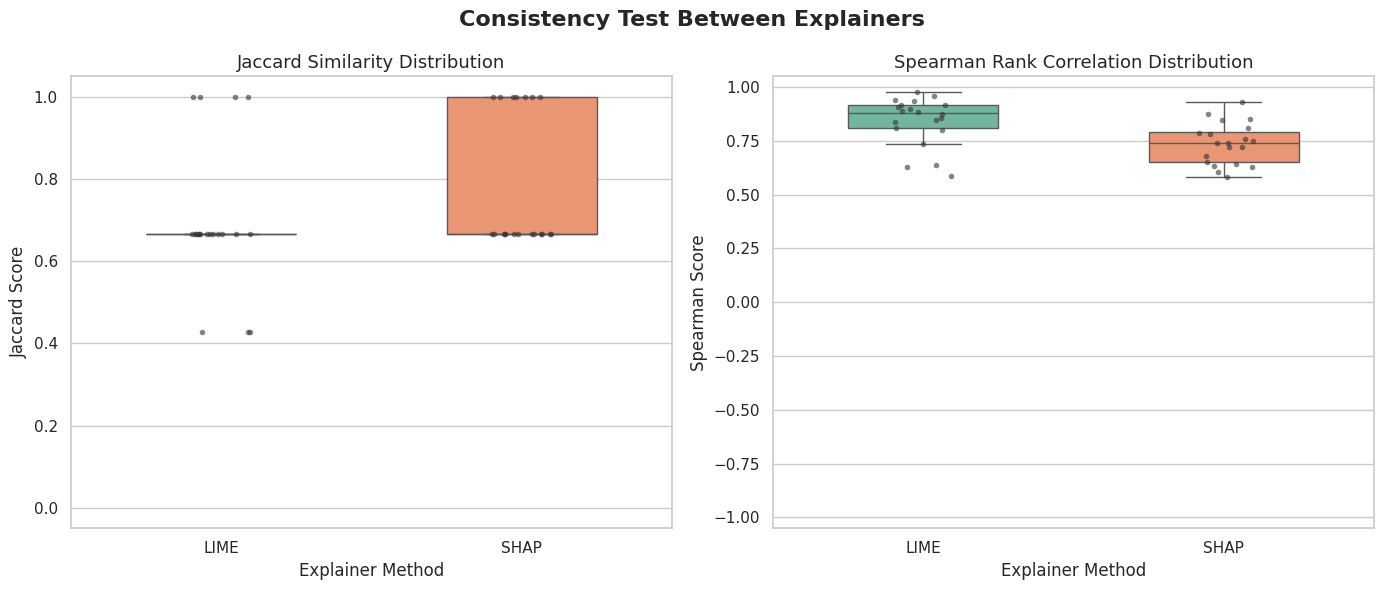

({'jaccard': [0.42857142857142855,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   1.0,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.42857142857142855,
   0.6666666666666666,
   0.42857142857142855],
  'spearman': [0.8,
   0.9575757575757575,
   0.9333333333333333,
   0.896969696969697,
   0.9757575757575757,
   0.8545454545454545,
   0.8121212121212121,
   0.8363636363636364,
   0.8484848484848485,
   0.6303030303030304,
   0.9151515151515152,
   0.9393939393939394,
   0.8727272727272728,
   0.9090909090909091,
   0.7333333333333334,
   0.9151515151515152,
   0.8848484848484849,
   0.6363636363636364,
   0.8909090909090909,
   0.5878787878787879]},
 {'jaccard': [1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   0.66666666666

In [5]:
loan_tester.consistency_test(display=True)

### Stability test

/home/alexis/UtilityAlignedExplainer/decision_maker.py:484: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jaccard, x="Explainer", y="Score", ax=axes[0], palette="Set2", showfliers=False, width=0.5)
/home/alexis/UtilityAlignedExplainer/decision_maker.py:491: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_spearman, x="Explainer", y="Score", ax=axes[1], palette="Set2", showfliers=False, width=0.5)


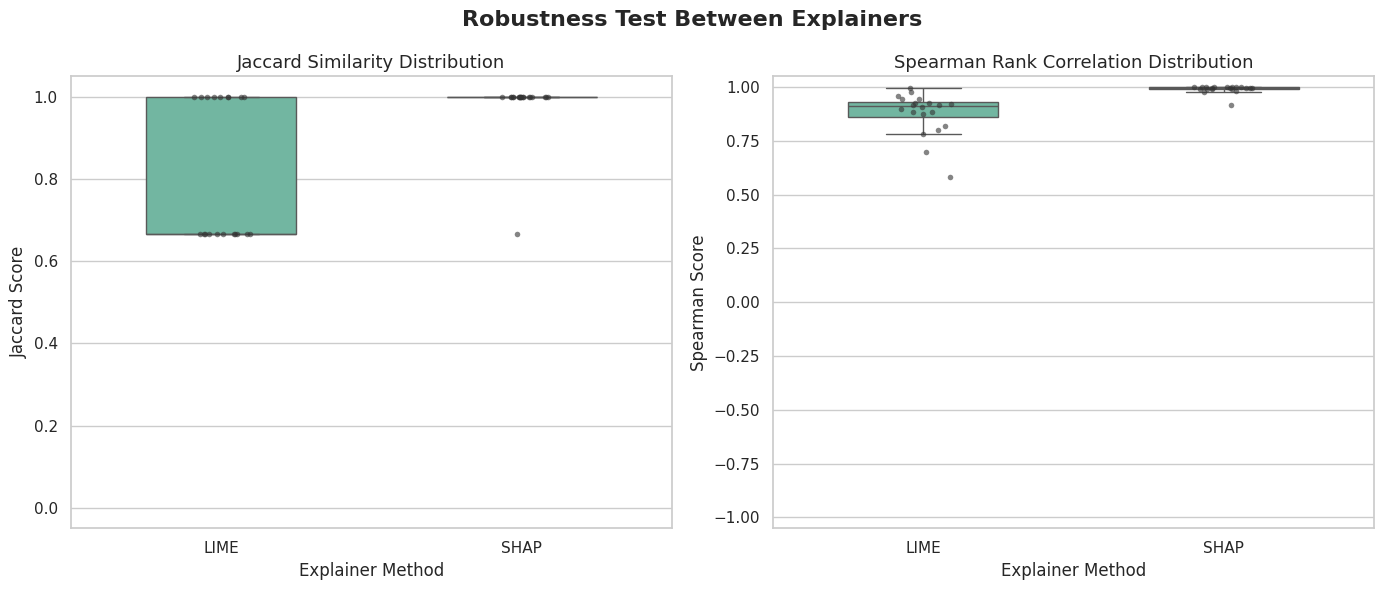

({'jaccard': [1.0,
   0.6666666666666666,
   1.0,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   1.0,
   1.0,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   1.0,
   0.6666666666666666,
   0.6666666666666666,
   0.6666666666666666,
   1.0],
  'spearman': [0.9939393939393939,
   0.5818181818181818,
   0.9575757575757575,
   0.9151515151515152,
   0.896969696969697,
   0.9454545454545454,
   0.8,
   0.8848484848484849,
   0.9090909090909091,
   0.8727272727272728,
   0.9212121212121213,
   0.9272727272727272,
   0.9151515151515152,
   0.7818181818181819,
   0.9272727272727272,
   0.9757575757575757,
   0.9454545454545454,
   0.8181818181818181,
   0.8848484848484849,
   0.696969696969697]},
 {'jaccard': [1.0,
   1.0,
   1.0,
   0.6666666666666666,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0],
  'spearman': [0.98

In [6]:
loan_tester.robustness_test(display=True)

/home/alexis/UtilityAlignedExplainer/decision_maker.py:525: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Explainer", y="Sensitivity", palette="Set2", showfliers=False, width=0.5)


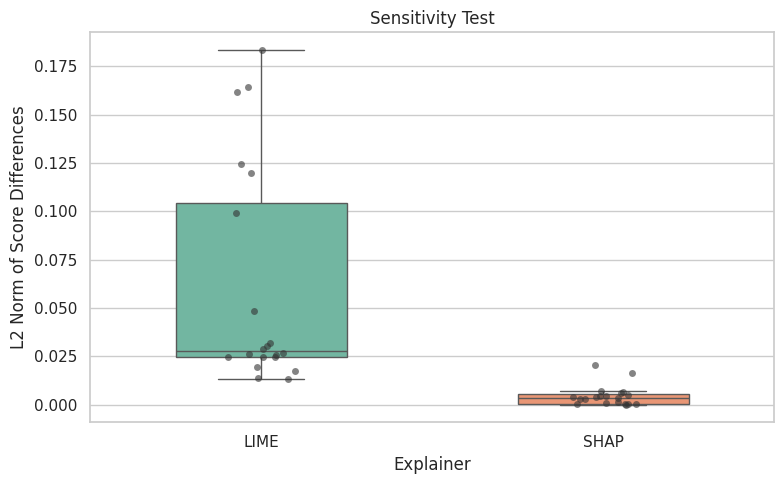

{'LIME': [np.float64(0.04855408156244081),
  np.float64(0.013625960984237882),
  np.float64(0.02457713946482344),
  np.float64(0.024591156140707213),
  np.float64(0.12458811575546244),
  np.float64(0.02642819473181678),
  np.float64(0.16450157531501505),
  np.float64(0.1196326120628065),
  np.float64(0.01928744418559891),
  np.float64(0.025831412096895247),
  np.float64(0.1834786969637498),
  np.float64(0.01719378014581082),
  np.float64(0.16200726494884882),
  np.float64(0.013034790654135254),
  np.float64(0.03182063414700792),
  np.float64(0.028596833610843822),
  np.float64(0.024443921782414255),
  np.float64(0.02621828857108715),
  np.float64(0.09893245535182042),
  np.float64(0.030148364974026585)],
 'SHAP': [np.float64(0.004160989971357527),
  np.float64(0.004546324239034238),
  np.float64(0.004544507634776695),
  np.float64(0.006167745591589015),
  np.float64(0.00316350065362555),
  np.float64(0.020249046654438954),
  np.float64(0.00024694406957428126),
  np.float64(0.0003351477

In [7]:
loan_tester.sensitivity_test(display=True)

### Fidelity test

/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:44:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:44:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:44:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:44:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alexis/.local/lib/

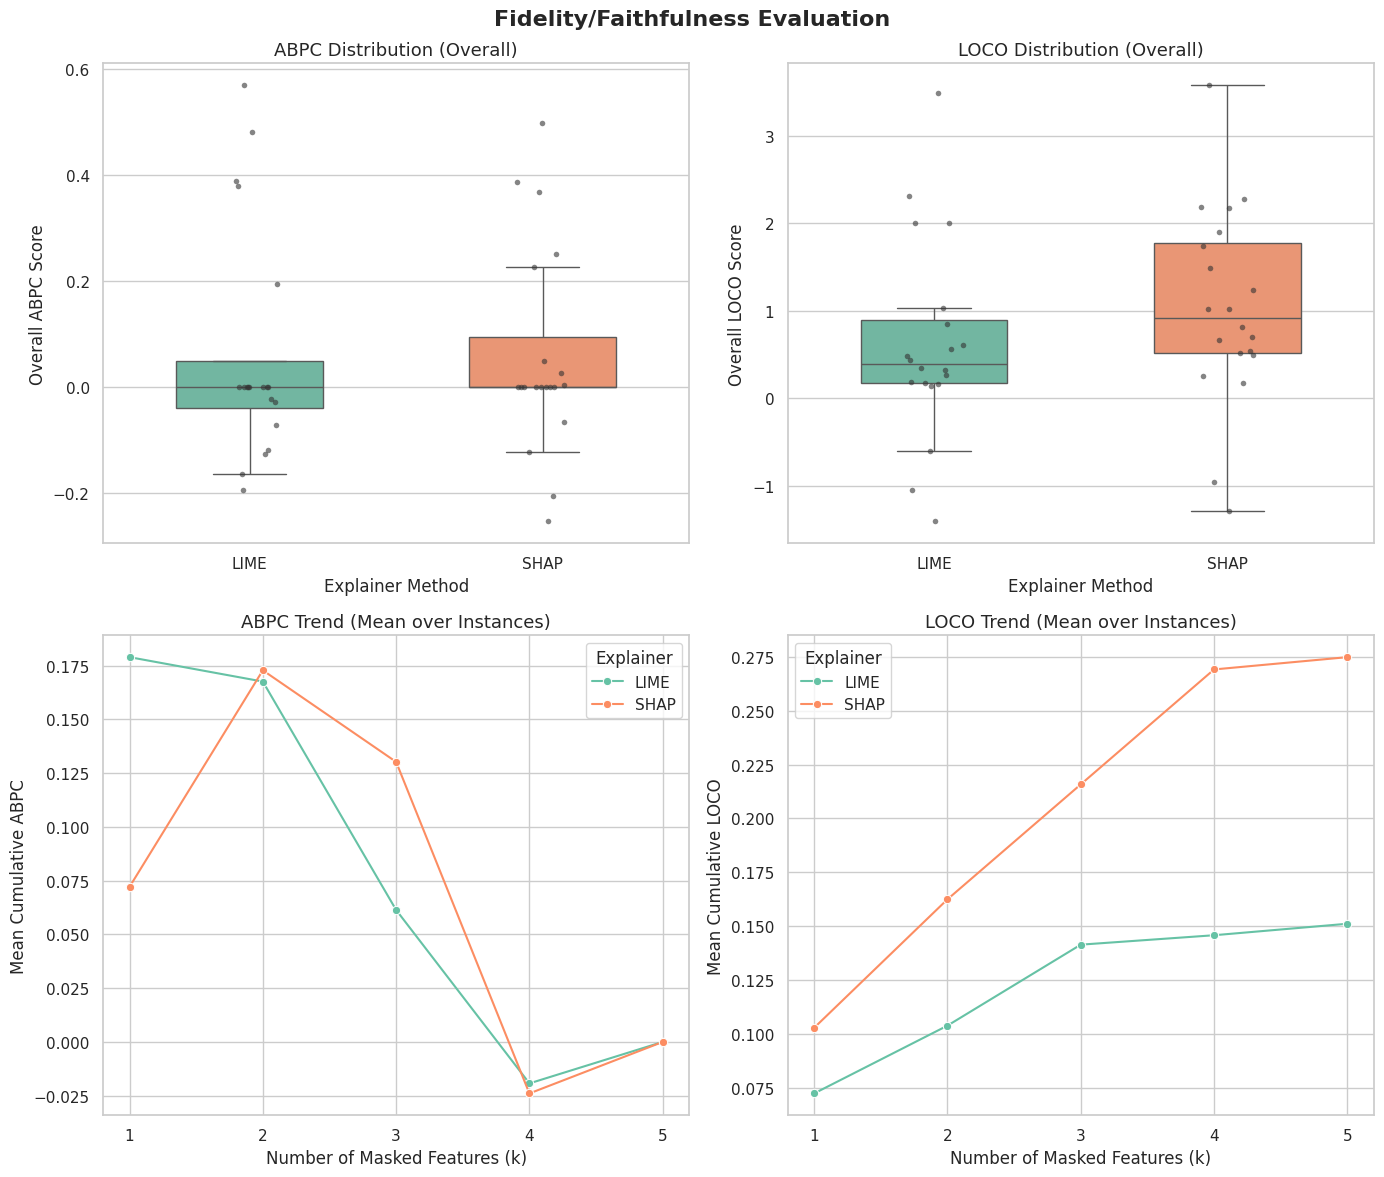

({'ABPC score': [np.float32(-0.0700516),
   np.float32(-3.774961e-06),
   np.float32(0.48216546),
   np.float32(1.4364721e-05),
   np.float32(0.5702658),
   np.float32(-0.028343419),
   np.float32(1.8080073e-06),
   np.float32(0.38962597),
   np.float32(-0.118471645),
   np.float32(-0.12572132),
   np.float32(0.38019475),
   np.float32(-0.19360192),
   np.float32(0.19578871),
   np.float32(1.7742317e-05),
   np.float32(-0.022361051),
   np.float32(-3.2275915e-05),
   np.float32(1.6778708e-05),
   np.float32(-0.16385886),
   np.float32(1.2119613e-06),
   np.float32(3.158053e-05)],
  'LOCO score': [np.float32(0.14094222),
   np.float32(0.60570973),
   np.float32(2.0053008),
   np.float32(0.84764373),
   np.float32(3.4877388),
   np.float32(0.48218745),
   np.float32(0.26597047),
   np.float32(1.9976285),
   np.float32(-1.0480928),
   np.float32(-0.60089344),
   np.float32(0.17965674),
   np.float32(0.32035273),
   np.float32(2.3123305),
   np.float32(0.55863667),
   np.float32(0.16151237

In [8]:
loan_tester.fidelity_test(display=True)

## Heart Disease

In [9]:
heart_disease = fetch_ucirepo(id=45)
X_heart = heart_disease.data.features.dropna()
y_heart = heart_disease.data.targets.loc[X_heart.index]
X_heart = X_heart.astype(float)
#X_heart = X_heart.reset_index(drop=True)
#y_heart = y_heart.reset_index(drop=True)
#X_heart = X_heart.apply(pd.to_numeric, errors='ignore')

In [10]:
heart_features = X_heart.columns.to_list()

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_heart, y_heart, test_size=0.2, random_state=RANDOM_SEED)

X_train_heart = X_train_heart.reset_index(drop=True)
X_test_heart = X_test_heart.reset_index(drop=True)
y_train_heart = y_train_heart.reset_index(drop=True)
y_test_heart = y_test_heart.reset_index(drop=True)

categorical_cols = X_heart.select_dtypes(include=['object']).columns.tolist()
heart_categorical_indices = [heart_features.index(col) for col in categorical_cols]
#encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

#preprocessor_heart = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

#X_train_processed_heart = pd.DataFrame(preprocessor_heart.fit_transform(X_train_heart), columns=heart_features, index=X_train_heart.index)
#X_test_processed_heart = pd.DataFrame(preprocessor_heart.transform(X_test_heart), columns=heart_features, index=X_test_heart.index)

heart_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
#heart_model1.fit(X_train_processed_heart, y_train_heart)
heart_model1.fit(X_train_heart, y_train_heart)

heart_model2 = DecisionTreeClassifier(random_state=RANDOM_SEED)
#heart_model2.fit(X_train_processed_heart, y_train_heart)
heart_model2.fit(X_train_heart, y_train_heart)

heart_model3 = XGBClassifier(random_state=RANDOM_SEED, use_label_encoder=False, eval_metric='logloss')
#heart_model3.fit(X_train_processed_heart, y_train_heart)
heart_model3.fit(X_train_heart, y_train_heart)

heart_models = [heart_model1, heart_model2, heart_model3]

#heart_models.sort(reverse=True,key=lambda model: evaluate_models(model, X_test_processed_heart, y_test_heart))
heart_models.sort(reverse=True,key=lambda model: evaluate_models(model, X_test_heart, y_test_heart))
heart_model = heart_models[0]

heart_class_names = [str(c) for c in sorted(np.unique(y_heart.values))]

/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alexis/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:45:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
heart_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_heart.values,
    feature_names=heart_features,
    class_names=heart_class_names, 
#    categorical_features=heart_categorical_indices,
#    discretize_continuous=False,
    mode='classification'
)

heart_shap_explainer = shap.Explainer(heart_model)

heart_tester = ReducedExplainerTester(
    model=heart_model,
    features=heart_features,
    X_train=X_train_heart,
    y_train=y_train_heart,
    X_test=X_test_heart,
    lime_explainer=heart_lime_explainer,
    shap_explainer=heart_shap_explainer,
    n_samples=20 
)

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

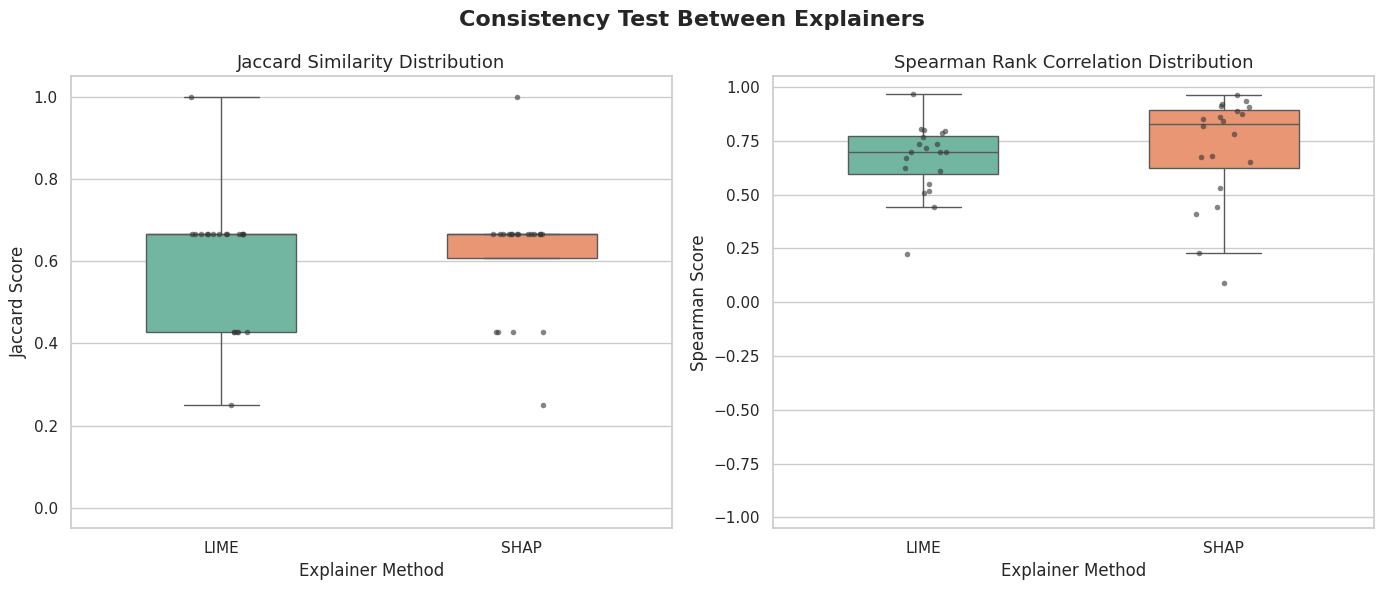

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

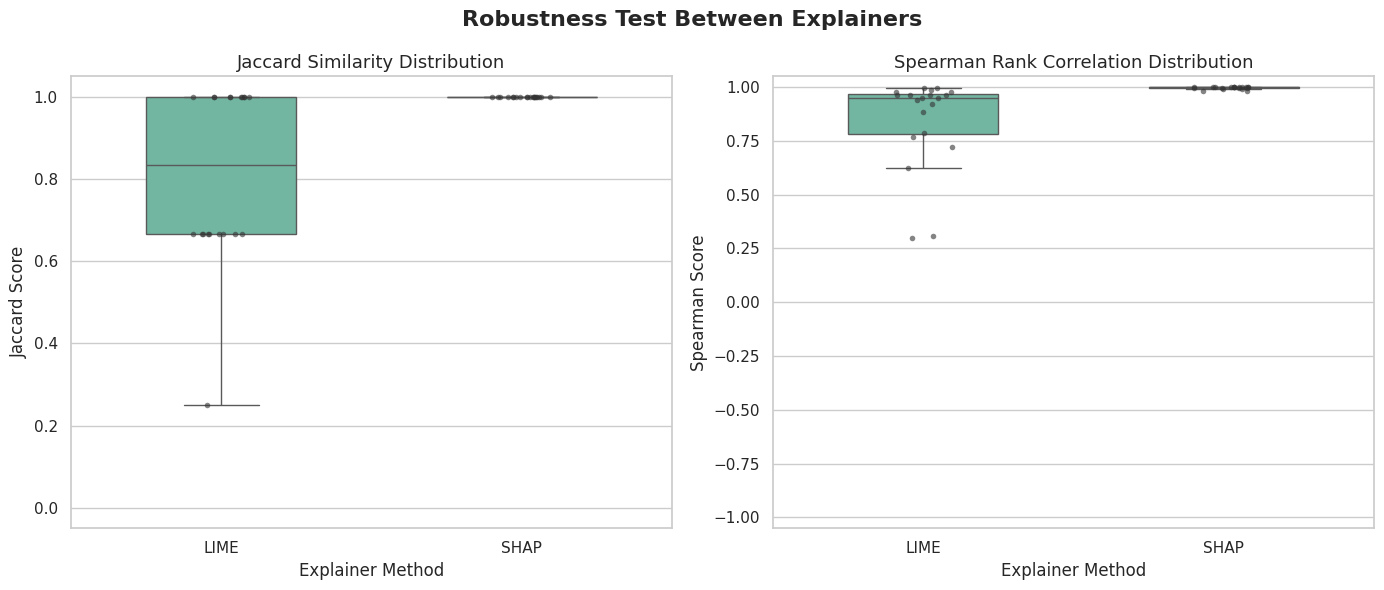

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

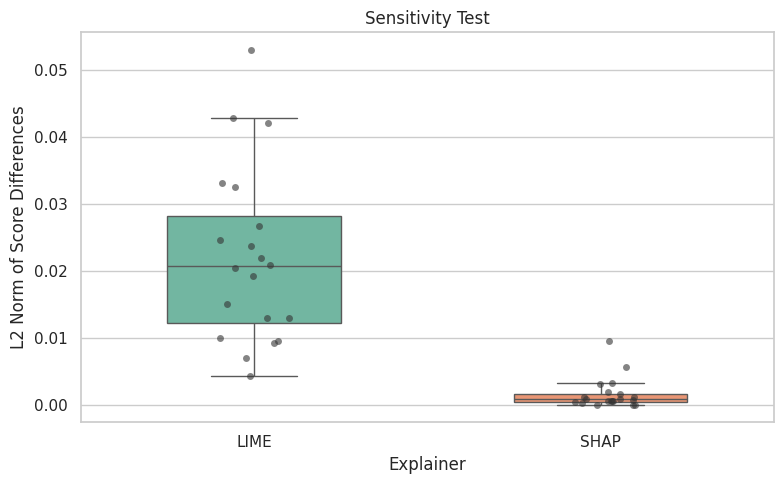

/home/alexis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method

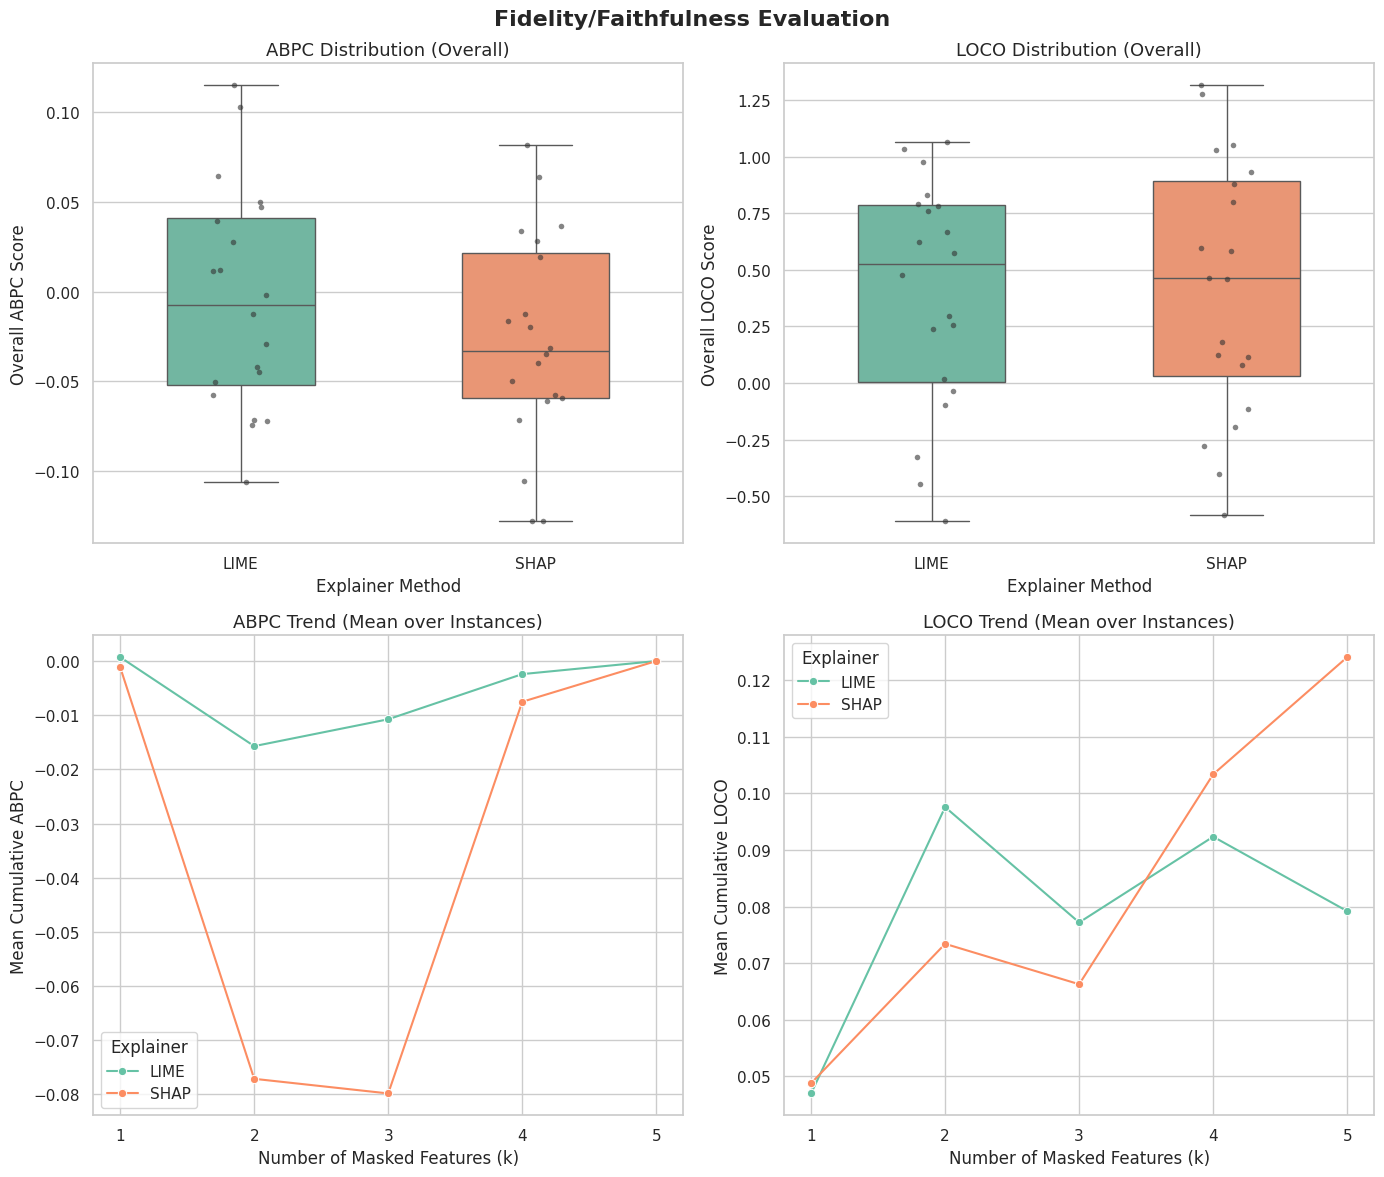

({'ABPC score': [np.float64(-0.012636782495920632),
   np.float64(-0.10623147986089373),
   np.float64(-0.028994924717417957),
   np.float64(0.11491002422876037),
   np.float64(-0.04486072441701894),
   np.float64(-0.07224221048896098),
   np.float64(0.027711536482873583),
   np.float64(0.01147573313999354),
   np.float64(0.04733528197053852),
   np.float64(0.10250592541387893),
   np.float64(0.012056010451136148),
   np.float64(-0.042268140655133804),
   np.float64(-0.0574088971328276),
   np.float64(-0.07437011027071977),
   np.float64(0.04968615582510852),
   np.float64(-0.07127196003152525),
   np.float64(-0.05052278597632544),
   np.float64(0.06430374364238171),
   np.float64(-0.0020603667744101273),
   np.float64(0.039040565468160426)],
  'LOCO score': [np.float64(0.7818772645220518),
   np.float64(-0.6112739072770792),
   np.float64(0.7905537010902255),
   np.float64(0.6235815768391982),
   np.float64(1.0312313097231363),
   np.float64(0.5733972196871973),
   np.float64(-0.32815

In [12]:
heart_tester.consistency_test(display=True)
heart_tester.robustness_test(display=True)
heart_tester.sensitivity_test(display=True)
heart_tester.fidelity_test(display=True)

## Adult Income dataset

In [ ]:
X, y = shap.datasets.adult()

In [ ]:
X.columns

## Iris dataset